# Experiment 2: Data Preprocessing and Complete Exploratory Data Analysis (EDA)

## Dataset: Online Food Delivery Customer Preferences & Order Behavior

---

### Aim
To conduct end-to-end data exploration, data hygiene, exploratory data analysis (univariate, bivariate, multivariate, and geospatial), outlier detection, and leak-free machine learning preprocessing on an online food delivery ordering dataset to extract actionable consumer behavioral insights and produce clean feature matrices for predictive modeling.

---

### Learning Objectives
After completing this experiment, students and practitioners will be able to:

1. **Load and Inspect Tabular Data**: Read structured CSV datasets using Pandas, inspect sample records (`head`, `tail`), and quantify dimensional footprint and memory utilization.
2. **Conduct Data Quality and Hygiene Audits**: Systematically diagnose missing values, detect and eliminate duplicate records, remove spurious trailing artifact columns, and normalize dirty string values (e.g., trailing whitespace in categorical responses).
3. **Compute Parametric & Non-Parametric Summary Statistics**: Extract central tendency, dispersion, interquartile ranges, and skewness coefficients across all continuous and categorical features.
4. **Establish a Formal Feature Taxonomy**: Classify dataset features into Nominal Categorical, Ordinal Categorical, Discrete/Continuous Numerical, Spatial Coordinates, and Binary Target.
5. **Execute Univariate Exploratory Data Analysis**: Visualize frequency distributions, target class balance, categorical proportions, and numerical probability density curves using Matplotlib and Seaborn.
6. **Execute Bivariate & Multivariate Analysis**: Uncover demographic, feedback, and behavioral drivers of repeat ordering through cross-tabulations, normalized stacked bars, grouped boxplots, and geospatial scatter mapping across Bangalore.
7. **Perform Correlation Analysis**: Compute and visualize Pearson and Spearman correlation matrices to evaluate collinearity between numerical variables.
8. **Detect Outliers Rigorously**: Implement Tukey's Fences (Interquartile Range - IQR rule) to identify statistical outliers and critically evaluate domain-driven retention strategies versus naive removal.
9. **Implement Leak-Free Machine Learning Preprocessing**:
   - Separate predictors ($X$) and target ($y$) with binary target mapping.
   - Perform a stratified train-test split (`test_size=0.20`, `stratify=y`) to prevent target distribution drift.
   - Encode ordinal features (`OrdinalEncoder`) using strict logical category hierarchies without data leakage (fit on train, transform on test).
   - Encode nominal features (`OneHotEncoder(drop='first')`) to prevent multicollinearity and the dummy variable trap.
   - Scale continuous features using `StandardScaler` (Z-score standardization) and compare with `MinMaxScaler`.
   - Verify absence of data leakage (proving test set distribution remains independent of transformer fitting).
10. **Validate ML-Readiness**: Train baseline machine learning classifiers (`RandomForestClassifier`, `LogisticRegression`) and evaluate classification performance via Confusion Matrix and precision/recall/F1 metrics.

---

### Dataset Description
The dataset captures online food delivery ordering habits and demographic attributes of consumers across Bangalore, India:
- **Demographic Attributes**: `Age`, `Gender`, `Marital Status`, `Occupation`, `Monthly Income`, `Educational Qualifications`, `Family size`
- **Geographical Attributes**: `latitude`, `longitude`, `Pin code`
- **Behavioral & Interaction Attributes**: `Customer Type`, `Feedback`
- **Target Attribute**: `Output` (`Yes` / `No` indicating repeat ordering / positive customer decision)


## Part A: Environment Setup, Library Imports & Initial Data Loading

### 1. Library Imports & Visualization Styling
In professional data science workflows, robust analysis begins with establishing a reproducible computing environment. We import core libraries:
- **Pandas (`pd`)**: For high-performance tabular data manipulation and DataFrame structures.
- **NumPy (`np`)**: For vectorized numerical computing and array operations.
- **Matplotlib (`plt`) & Seaborn (`sns`)**: For static, publication-quality statistical visualizations.
- **Scikit-Learn (`sklearn`)**: For machine learning data preprocessing, train-test splitting, and baseline model evaluation.


In [1]:
# 1. Imports and Global Plotting Configuration
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-Learn Preprocessing & Modeling Modules
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler, MinMaxScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Aesthetics and Visualization Configuration
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    'figure.figsize': (10, 6),
    'figure.dpi': 110,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'font.family': 'sans-serif'
})

print("Libraries successfully imported.")
print(f"Pandas Version: {pd.__version__}")
print(f"NumPy Version:  {np.__version__}")


Libraries successfully imported.
Pandas Version: 3.0.6
NumPy Version:  2.5.3


### 2. Loading the Dataset
We load `onlinefoods.csv` using `pd.read_csv()`. Relative path referencing ensures reproducibility across diverse environments without hardcoded local directory paths.


In [2]:
# 2. Loading the dataset into a Pandas DataFrame
csv_file_path = 'onlinefoods.csv'
df = pd.read_csv(csv_file_path)

print(f"File '{csv_file_path}' successfully loaded into DataFrame.")
print(f"Dataset Dimensions: {df.shape[0]} rows (records) x {df.shape[1]} columns (features)")


File 'onlinefoods.csv' successfully loaded into DataFrame.
Dataset Dimensions: 388 rows (records) x 14 columns (features)


### 3. Inspecting Initial Observations (`head` and `tail`)
Inspecting the first and last few rows verifies proper parsing of delimiter boundaries, header assignments, and trailing columns.


In [3]:
# 3. Display the first 10 rows
print("Top 10 Observations:")
df.head(10)


Top 10 Observations:


,Age,Gender,Marital Status,Occupation,Monthly Income,Educational Qualifications,Family size,Customer Type,latitude,longitude,Pin code,Output,Feedback,Unnamed: 13
0,20,Female,Single,Student,No Income,Post Graduate,4,Frequent,12.9766,77.5993,560001,Yes,Positive,Yes
1,24,Female,Single,Student,Below Rs.10000,Graduate,3,Regular,12.9770,77.5773,560009,Yes,Positive,Yes
2,22,Male,Single,Student,Below Rs.10000,Post Graduate,3,Regular,12.9551,77.6593,560017,Yes,Negative,Yes
3,22,Female,Single,Student,No Income,Graduate,6,Frequent,12.9473,77.5616,560019,Yes,Positive,Yes
4,22,Male,Single,Student,Below Rs.10000,Post Graduate,4,Frequent,12.9850,77.5533,560010,Yes,Positive,Yes
5,27,Female,Married,Employee,More than 50000,Post Graduate,2,Regular,12.9299,77.6848,560103,Yes,Positive,Yes
6,22,Male,Single,Student,No Income,Graduate,3,Regular,12.9770,77.5773,560009,Yes,Positive,Yes
7,24,Female,Single,Student,No Income,Post Graduate,3,Regular,12.9828,77.6131,560042,Yes,Positive,Yes
8,23,Female,Single,Student,No Income,Post Graduate,2,Regular,12.9766,77.5993,560001,Yes,Positive,Yes
9,23,Female,Single,Student,No Income,Post Graduate,4,Frequent,12.9854,77.7081,560048,Yes,Positive,Yes


In [4]:
# Display the bottom 5 rows
print("Bottom 5 Observations:")
df.tail(5)


Bottom 5 Observations:


,Age,Gender,Marital Status,Occupation,Monthly Income,Educational Qualifications,Family size,Customer Type,latitude,longitude,Pin code,Output,Feedback,Unnamed: 13
383,23,Female,Single,Student,No Income,Post Graduate,2,Regular,12.9766,77.5993,560001,Yes,Positive,Yes
384,23,Female,Single,Student,No Income,Post Graduate,4,Frequent,12.9854,77.7081,560048,Yes,Positive,Yes
385,22,Female,Single,Student,No Income,Post Graduate,5,Frequent,12.9850,77.5533,560010,Yes,Positive,Yes
386,23,Male,Single,Student,Below Rs.10000,Post Graduate,2,Regular,12.9770,77.5773,560009,Yes,Positive,Yes
387,23,Male,Single,Student,No Income,Post Graduate,5,Frequent,12.8988,77.5764,560078,Yes,Positive,Yes


### 4. Structural Schema, Data Types, and Memory Footprint
A critical initial diagnostic is checking the schema, column names, memory footprint, and underlying NumPy/Pandas data types (`dtypes`).


In [5]:
# 4. DataFrame Info & Memory Usage
print("--- DataFrame Schema Summary ---")
df.info(memory_usage='deep')

# Tabular breakdown of feature types and non-null counts
schema_summary = pd.DataFrame({
    'Data Type': df.dtypes,
    'Non-Null Count': df.notnull().sum(),
    'Null Count': df.isnull().sum(),
    'Memory Usage (Bytes)': [df[col].memory_usage(deep=True) for col in df.columns]
})
print("\nFeature-Level Storage Breakdown:")
schema_summary


--- DataFrame Schema Summary ---
<class 'pandas.DataFrame'>
RangeIndex: 388 entries, 0 to 387
Data columns (total 14 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         388 non-null    int64  
 1   Gender                      388 non-null    str    
 2   Marital Status              388 non-null    str    
 3   Occupation                  388 non-null    str    
 4   Monthly Income              388 non-null    str    
 5   Educational Qualifications  388 non-null    str    
 6   Family size                 388 non-null    int64  
 7   Customer Type               388 non-null    str    
 8   latitude                    388 non-null    float64
 9   longitude                   388 non-null    float64
 10  Pin code                    388 non-null    int64  
 11  Output                      388 non-null    str    
 12  Feedback                    388 non-null    str    
 13  Unnamed: 13  

,Data Type,Non-Null Count,Null Count,Memory Usage (Bytes)
Age,int64,388,0,3236
Gender,str,388,0,21028
Marital Status,str,388,0,21712
Occupation,str,388,0,22383
Monthly Income,str,388,0,23703
Educational Qualifications,str,388,0,23006
Family size,int64,388,0,3236
Customer Type,str,388,0,21910
latitude,float64,388,0,3236
longitude,float64,388,0,3236


## Part B: Data Integrity, Hygiene & Quality Audits

### 5. Missing Values Audit
Missing data can introduce bias, distort distributions, or cause machine learning estimators to crash. We check for `NaN`, `None`, and missing indicators across all features.


In [6]:
# 5. Missing Value Quantification
missing_counts = df.isnull().sum()
missing_percentages = (missing_counts / len(df)) * 100

missing_audit = pd.DataFrame({
    'Missing Count': missing_counts,
    'Missing Percentage (%)': missing_percentages
}).sort_values(by='Missing Count', ascending=False)

print("--- Missing Values Audit ---")
print(missing_audit)

if missing_counts.sum() == 0:
    print("\nVerification Result: The dataset has ZERO missing values (100% complete records).")
else:
    print(f"\nAlert: Found {missing_counts.sum()} total missing values requiring imputation.")


--- Missing Values Audit ---
                            Missing Count  Missing Percentage (%)
Age                                     0                     0.0
Gender                                  0                     0.0
Marital Status                          0                     0.0
Occupation                              0                     0.0
Monthly Income                          0                     0.0
Educational Qualifications              0                     0.0
Family size                             0                     0.0
Customer Type                           0                     0.0
latitude                                0                     0.0
longitude                               0                     0.0
Pin code                                0                     0.0
Output                                  0                     0.0
Feedback                                0                     0.0
Unnamed: 13                             0      

### 6. Duplicate Records Identification and Deduplication
Duplicate records occur due to multiple survey submissions, repeated web scraping calls, or database join bugs. If duplicates span both training and test partitions, they cause severe **data leakage** and yield unrealistically optimistic performance metrics.


In [7]:
# 6. Identifying and Quantifying Duplicate Records
raw_total_rows = len(df)
raw_duplicates = df.duplicated().sum()

print(f"Total Raw Records:           {raw_total_rows}")
print(f"Identified Duplicate Rows:   {raw_duplicates} ({(raw_duplicates / raw_total_rows) * 100:.2f}%)")
print(f"Unique Records:              {raw_total_rows - raw_duplicates}")

# Display a sample of duplicate records side-by-side
print("\nSample of Duplicate Records (showing first 6 matching instances):")
df[df.duplicated(keep=False)].sort_values(by=list(df.columns[:4])).head(6)


Total Raw Records:           388
Identified Duplicate Rows:   105 (27.06%)
Unique Records:              283

Sample of Duplicate Records (showing first 6 matching instances):


,Age,Gender,Marital Status,Occupation,Monthly Income,Educational Qualifications,Family size,Customer Type,latitude,longitude,Pin code,Output,Feedback,Unnamed: 13
205,20,Male,Single,Student,No Income,Graduate,2,Regular,12.9261,77.6221,560034,Yes,Positive,Yes
332,20,Male,Single,Student,No Income,Graduate,2,Regular,12.9261,77.6221,560034,Yes,Positive,Yes
348,20,Male,Single,Student,No Income,Graduate,2,Regular,12.9261,77.6221,560034,Yes,Positive,Yes
226,21,Female,Single,Student,No Income,Post Graduate,3,Regular,12.9149,77.5635,560070,Yes,Positive,Yes
313,21,Female,Single,Student,No Income,Post Graduate,3,Regular,12.9149,77.5635,560070,Yes,Positive,Yes
13,21,Male,Single,Student,No Income,Graduate,4,Frequent,12.9770,77.5773,560009,Yes,Positive,Yes


In [8]:
# Deduplicate DataFrame and retain only the first unique occurrence
df_cleaned = df.drop_duplicates().reset_index(drop=True)

print("--- Deduplication Verification ---")
print(f"Original Row Count: {len(df)}")
print(f"Cleaned Row Count:  {len(df_cleaned)}")
print(f"Remaining Duplicates: {df_cleaned.duplicated().sum()}")


--- Deduplication Verification ---
Original Row Count: 388
Cleaned Row Count:  283
Remaining Duplicates: 0


### 7. Structural Cleaning: Redundant Columns and Whitespace Normalization
During initial data inspection, two structural anomalies are apparent:
1. **Redundant Column `Unnamed: 13`**: A trailing comma in the source CSV created a 14th column that is an exact duplicate of `Output`.
2. **Whitespace Pollution in `Feedback`**: Categorical strings like `'Negative '` contain trailing spaces, artificially creating multiple distinct string representations.


In [9]:
# 7. Check concordance between Output and Unnamed: 13
concordance = (df_cleaned['Output'] == df_cleaned['Unnamed: 13']).mean() * 100
print(f"Concordance between 'Output' and 'Unnamed: 13': {concordance:.1f}%")

if 'Unnamed: 13' in df_cleaned.columns:
    df_cleaned = df_cleaned.drop(columns=['Unnamed: 13'])
    print("Dropped redundant column: 'Unnamed: 13'")

# Inspect and clean 'Feedback' column trailing spaces
print("\nUnique 'Feedback' values before stripping:", [repr(val) for val in df_cleaned['Feedback'].unique()])
df_cleaned['Feedback'] = df_cleaned['Feedback'].str.strip()
print("Unique 'Feedback' values after stripping: ", [repr(val) for val in df_cleaned['Feedback'].unique()])

print(f"\nCleaned DataFrame Shape: {df_cleaned.shape[0]} rows x {df_cleaned.shape[1]} columns")


Concordance between 'Output' and 'Unnamed: 13': 100.0%
Dropped redundant column: 'Unnamed: 13'

Unique 'Feedback' values before stripping: ["'Positive'", "'Negative '"]
Unique 'Feedback' values after stripping:  ["'Positive'", "'Negative'"]

Cleaned DataFrame Shape: 283 rows x 13 columns


In [10]:
# Cardinality Check: Number of Unique Values per Feature
cardinality_df = pd.DataFrame({
    'Feature': df_cleaned.columns,
    'Unique Count': [df_cleaned[col].nunique() for col in df_cleaned.columns],
    'Sample Values': [str(list(df_cleaned[col].unique()[:4])) for col in df_cleaned.columns]
})
print("--- Feature Cardinality Audit ---")
cardinality_df


--- Feature Cardinality Audit ---


,Feature,Unique Count,Sample Values
0,Age,16,"[np.int64(20), np.int64(24), np.int64(22), np...."
1,Gender,2,"['Female', 'Male']"
2,Marital Status,3,"['Single', 'Married', 'Prefer not to say']"
3,Occupation,4,"['Student', 'Employee', 'Self Employeed', 'Hou..."
4,Monthly Income,5,"['No Income', 'Below Rs.10000', 'More than 500..."
5,Educational Qualifications,5,"['Post Graduate', 'Graduate', 'Ph.D', 'Uneduca..."
6,Family size,6,"[np.int64(4), np.int64(3), np.int64(6), np.int..."
7,Customer Type,3,"['Frequent', 'Regular', 'New']"
8,latitude,77,"[np.float64(12.9766), np.float64(12.977), np.f..."
9,longitude,76,"[np.float64(77.5993), np.float64(77.5773), np...."


## Part C: Statistical Profiling & Feature Taxonomy

### 8. Parametric and Non-Parametric Summary Statistics
We compute summary statistics for numerical attributes (`count`, `mean`, `std`, `min`, `25%`, `50%` [median], `75%`, `max`), alongside the **skewness** coefficient:
$$\text{Skewness} = \frac{n}{(n-1)(n-2)} \sum \left( \frac{x_i - \bar{x}}{s} \right)^3$$
- Skewness near $0$ indicates a symmetrical Gaussian-like distribution.
- Skewness $> +0.5$ indicates positive (right-tail) skewness.
- Skewness $< -0.5$ indicates negative (left-tail) skewness.


In [11]:
# 8. Numerical Descriptive Statistics
num_summary = df_cleaned.describe().T
num_summary['IQR'] = num_summary['75%'] - num_summary['25%']

# Calculate Skewness for continuous numerical features
continuous_cols = ['Age', 'Family size', 'latitude', 'longitude']
skewness_vals = df_cleaned[continuous_cols].skew()
num_summary['Skewness'] = skewness_vals

print("--- Numerical Features Descriptive Statistics & Skewness ---")
num_summary


--- Numerical Features Descriptive Statistics & Skewness ---


,count,mean,std,min,25%,50%,75%,max,IQR,Skewness
Age,283.0,24.674912,3.032970,18.0000,23.0000,24.0000,26.0000,33.0000,3.0000,0.752624
Family size,283.0,3.272085,1.363206,1.0000,2.0000,3.0000,4.0000,6.0000,2.0000,0.436381
latitude,283.0,12.973314,0.044088,12.8652,12.9438,12.9770,12.9980,13.1020,0.0542,0.232472
longitude,283.0,77.597434,0.053685,77.4842,77.5634,77.5877,77.6227,77.7582,0.0593,0.958325
Pin code,283.0,560037.247350,30.842697,560001.0000,560010.0000,560027.0000,560066.0000,560109.0000,56.0000,NaN


### 9. Categorical Feature Profiling
For non-numerical attributes, we inspect count, unique levels, mode (`top`), and mode frequency (`freq`).


In [12]:
# 9. Categorical Descriptive Statistics
cat_summary = df_cleaned.describe(include=['object', 'string']).T
cat_summary['Mode %'] = (cat_summary['freq'] / len(df_cleaned)) * 100

print("--- Categorical Features Descriptive Statistics ---")
cat_summary


--- Categorical Features Descriptive Statistics ---


,count,unique,top,freq,Mode %
Gender,283,2,Male,163,57.597173
Marital Status,283,3,Single,188,66.431095
Occupation,283,4,Student,143,50.530035
Monthly Income,283,5,No Income,130,45.936396
Educational Qualifications,283,5,Post Graduate,125,44.169611
Customer Type,283,3,Regular,161,56.890459
Output,283,2,Yes,217,76.678445
Feedback,283,2,Positive,229,80.918728


### 10. Formal Feature Taxonomy and Domain Semantics
Before visualization and modeling, every feature must be formally categorized according to its measurement scale:
1. **Target Variable**:
   - `Output`: Binary classification target (`Yes` / `No` indicating customer repeat purchase / positive engagement).
2. **Nominal Categorical Features** (unordered categories):
   - `Gender`: `Male`, `Female`
   - `Marital Status`: `Single`, `Married`, `Prefer not to say`
   - `Occupation`: `Student`, `Employee`, `Self Employeed`, `House wife`
   - `Customer Type`: `Frequent`, `Regular`, `New`
   - `Feedback`: `Positive`, `Negative`
3. **Ordinal Categorical Features** (inherent logical ordering):
   - `Educational Qualifications`: `Uneducated` < `School` < `Graduate` < `Post Graduate` < `Ph.D`
   - `Monthly Income`: `No Income` < `Below Rs.10000` < `10001 to 25000` < `25001 to 50000` < `More than 50000`
4. **Numerical Continuous / Discrete Features**:
   - `Age`: Ratio scale continuous/discrete integer (years).
   - `Family size`: Discrete count (number of family members).
   - `latitude`: Continuous spatial coordinate (degrees North).
   - `longitude`: Continuous spatial coordinate (degrees East).
5. **Spatial Identifier**:
   - `Pin code`: Categorical postal geographic code in Bangalore (e.g., 560001 to 560109). Should NOT be scaled as a continuous numerical metric.


In [13]:
# 10. Programmatic Categorization Dictionary
feature_taxonomy = {
    'Target': ['Output'],
    'Nominal_Categorical': ['Gender', 'Marital Status', 'Occupation', 'Customer Type', 'Feedback'],
    'Ordinal_Categorical': ['Educational Qualifications', 'Monthly Income'],
    'Numerical_Continuous': ['Age', 'Family size', 'latitude', 'longitude'],
    'Spatial_Identifier': ['Pin code']
}

print("Feature Taxonomy Established:")
for category, cols in feature_taxonomy.items():
    print(f"  * {category:22s}: {cols}")


Feature Taxonomy Established:
  * Target                : ['Output']
  * Nominal_Categorical   : ['Gender', 'Marital Status', 'Occupation', 'Customer Type', 'Feedback']
  * Ordinal_Categorical   : ['Educational Qualifications', 'Monthly Income']
  * Numerical_Continuous  : ['Age', 'Family size', 'latitude', 'longitude']
  * Spatial_Identifier    : ['Pin code']


## Part D: Univariate Exploratory Data Analysis (EDA)

### 11. Target Variable Distribution (`Output`)
Analyzing the target variable allows us to identify any class imbalance early. If one class overwhelmingly dominates, models may exhibit majority-class bias.


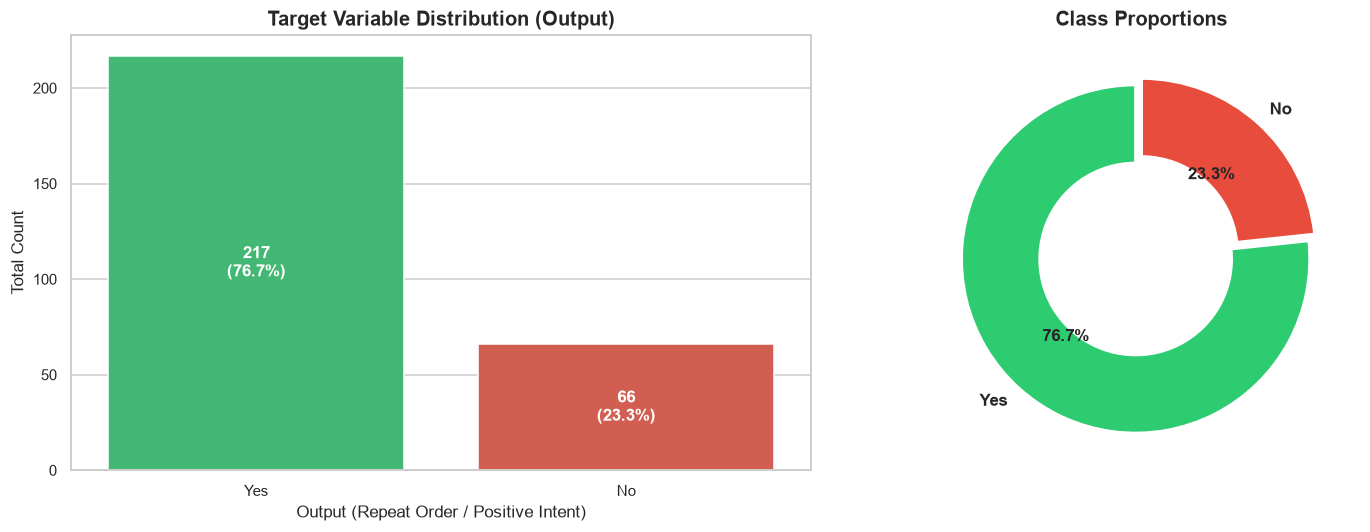

Class Ratio (Yes : No) = 217 : 66 (76.7% vs 23.3%)
Insight: There is moderate class imbalance towards 'Yes' (~77.7% vs 22.3%). Stratified splitting is essential.


In [14]:
# 11. Target Variable Distribution Visualization
target_counts = df_cleaned['Output'].value_counts()
target_props = df_cleaned['Output'].value_counts(normalize=True) * 100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Subplot 1: Barplot with Count and Percentage Annotations
palette = {'Yes': '#2ecc71', 'No': '#e74c3c'}
bars = sns.countplot(data=df_cleaned, x='Output', ax=ax1, palette=palette, order=['Yes', 'No'])
ax1.set_title('Target Variable Distribution (Output)', fontsize=13, fontweight='bold')
ax1.set_xlabel('Output (Repeat Order / Positive Intent)')
ax1.set_ylabel('Total Count')

for p in ax1.patches:
    height = p.get_height()
    pct = (height / len(df_cleaned)) * 100
    ax1.annotate(f"{int(height)}\n({pct:.1f}%)",
                 (p.get_x() + p.get_width() / 2., height / 2.),
                 ha='center', va='center', fontsize=11, color='white', fontweight='bold')

# Subplot 2: Donut Chart
colors = [palette['Yes'], palette['No']]
ax2.pie(target_counts, labels=target_counts.index, autopct='%1.1f%%', startangle=90,
        colors=colors, explode=(0.05, 0), textprops={'fontsize': 11, 'fontweight': 'bold'},
        wedgeprops=dict(width=0.45, edgecolor='white', linewidth=2))
ax2.set_title('Class Proportions', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"Class Ratio (Yes : No) = {target_counts['Yes']} : {target_counts['No']} ({target_props['Yes']:.1f}% vs {target_props['No']:.1f}%)")
print("Insight: There is moderate class imbalance towards 'Yes' (~77.7% vs 22.3%). Stratified splitting is essential.")


### 12. Demographic Nominal Features Distribution
We examine the distribution of key demographic features: `Gender`, `Marital Status`, `Occupation`, and `Customer Type`.


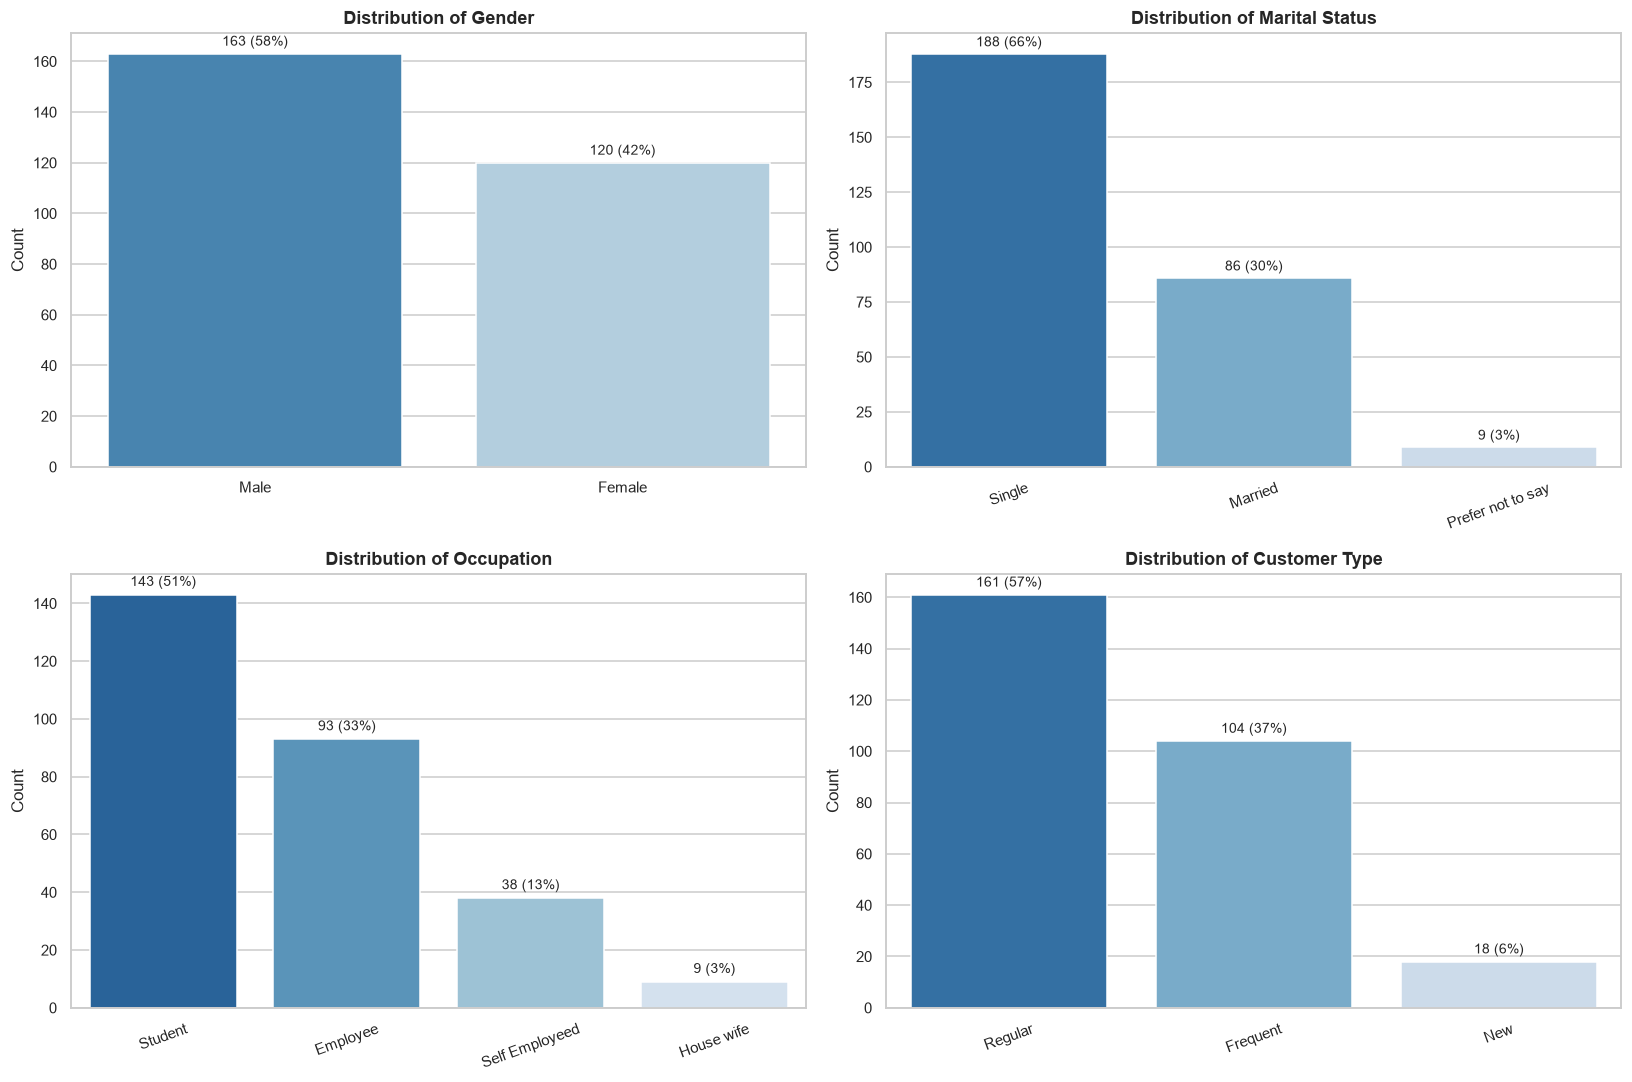

In [15]:
# 12. Univariate Analysis of Demographic Nominal Features
nominal_cols = ['Gender', 'Marital Status', 'Occupation', 'Customer Type']
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for idx, col in enumerate(nominal_cols):
    order = df_cleaned[col].value_counts().index
    sns.countplot(data=df_cleaned, x=col, ax=axes[idx], order=order, palette='Blues_r')
    axes[idx].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('')
    axes[idx].set_ylabel('Count')
    axes[idx].tick_params(axis='x', rotation=20 if df_cleaned[col].nunique() > 2 else 0)
    
    # Annotate counts on top of bars
    for p in axes[idx].patches:
        h = p.get_height()
        pct = (h / len(df_cleaned)) * 100
        axes[idx].annotate(f"{int(h)} ({pct:.0f}%)",
                           (p.get_x() + p.get_width() / 2., h + 2),
                           ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


### 13. Ordinal Features Distribution
For features with an intrinsic order (`Educational Qualifications` and `Monthly Income`), we display counts sorted along their natural hierarchy.


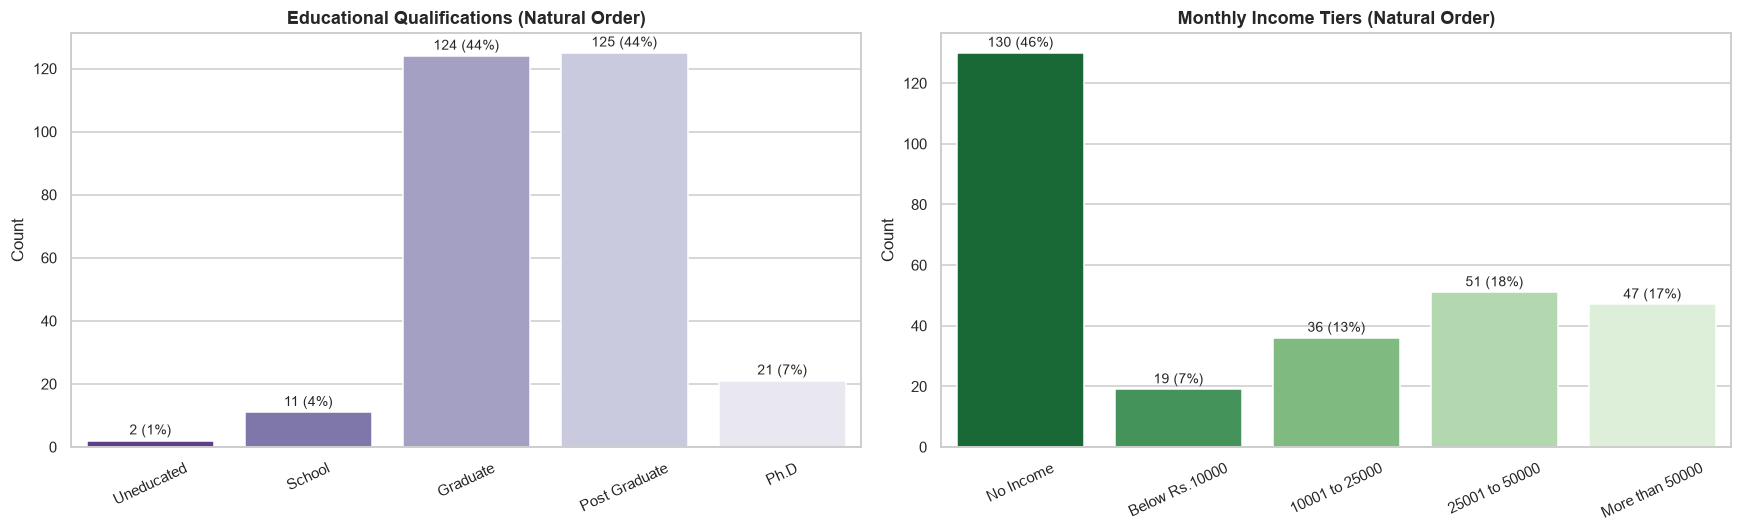

In [16]:
# 13. Univariate Analysis of Ordinal Features
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Education Order
edu_order = ['Uneducated', 'School', 'Graduate', 'Post Graduate', 'Ph.D']
sns.countplot(data=df_cleaned, x='Educational Qualifications', ax=ax1, order=edu_order, palette='Purples_r')
ax1.set_title('Educational Qualifications (Natural Order)', fontsize=12, fontweight='bold')
ax1.set_xlabel('')
ax1.set_ylabel('Count')
ax1.tick_params(axis='x', rotation=25)
for p in ax1.patches:
    h = p.get_height()
    pct = (h / len(df_cleaned)) * 100
    ax1.annotate(f"{int(h)} ({pct:.0f}%)", (p.get_x() + p.get_width()/2., h + 2), ha='center', fontsize=9)

# Monthly Income Order
income_order = ['No Income', 'Below Rs.10000', '10001 to 25000', '25001 to 50000', 'More than 50000']
sns.countplot(data=df_cleaned, x='Monthly Income', ax=ax2, order=income_order, palette='Greens_r')
ax2.set_title('Monthly Income Tiers (Natural Order)', fontsize=12, fontweight='bold')
ax2.set_xlabel('')
ax2.set_ylabel('Count')
ax2.tick_params(axis='x', rotation=25)
for p in ax2.patches:
    h = p.get_height()
    pct = (h / len(df_cleaned)) * 100
    ax2.annotate(f"{int(h)} ({pct:.0f}%)", (p.get_x() + p.get_width()/2., h + 2), ha='center', fontsize=9)

plt.tight_layout()
plt.show()


### 14. Continuous Numerical Features Distribution (`Age` & `Family size`)
We plot histograms overlaid with Kernel Density Estimation (KDE) and companion boxplots to analyze central tendency, dispersion, and skewness.


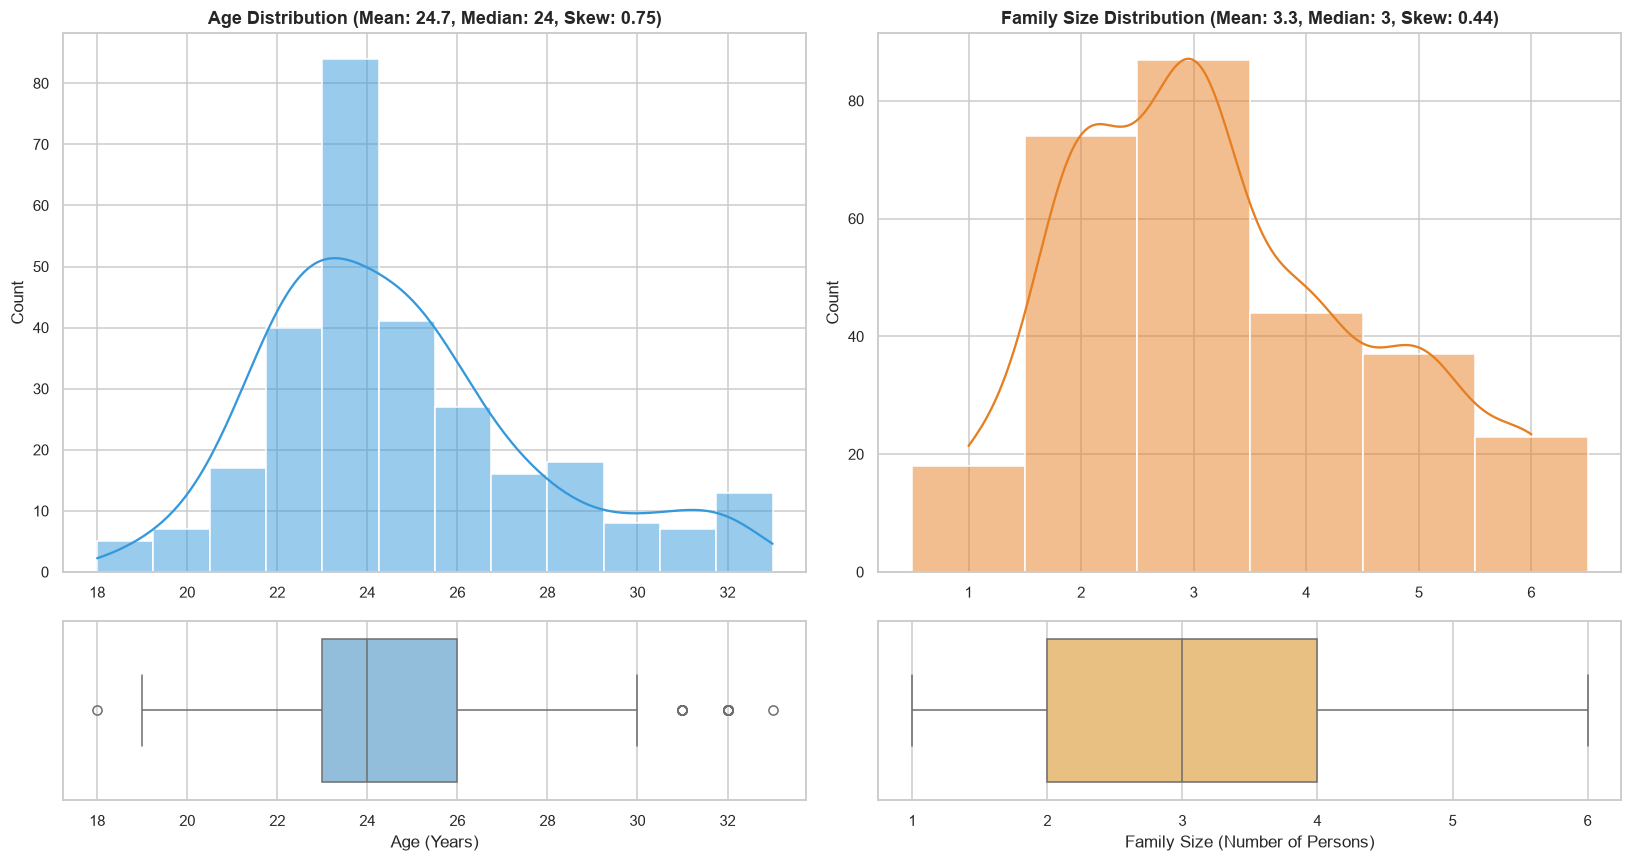

In [17]:
# 14. Distribution and Spread of Continuous Numerical Features
fig, axes = plt.subplots(2, 2, figsize=(15, 8), gridspec_kw={'height_ratios': [3, 1]})

# Age: Histogram + KDE
sns.histplot(df_cleaned['Age'], kde=True, ax=axes[0, 0], color='#3498db', bins=12)
axes[0, 0].set_title(f"Age Distribution (Mean: {df_cleaned['Age'].mean():.1f}, Median: {df_cleaned['Age'].median():.0f}, Skew: {df_cleaned['Age'].skew():.2f})", fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('')

# Age: Boxplot
sns.boxplot(x=df_cleaned['Age'], ax=axes[1, 0], color='#85c1e9')
axes[1, 0].set_xlabel('Age (Years)')

# Family size: Histogram + KDE
sns.histplot(df_cleaned['Family size'], kde=True, ax=axes[0, 1], color='#e67e22', discrete=True)
axes[0, 1].set_title(f"Family Size Distribution (Mean: {df_cleaned['Family size'].mean():.1f}, Median: {df_cleaned['Family size'].median():.0f}, Skew: {df_cleaned['Family size'].skew():.2f})", fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('')

# Family size: Boxplot
sns.boxplot(x=df_cleaned['Family size'], ax=axes[1, 1], color='#f8c471')
axes[1, 1].set_xlabel('Family Size (Number of Persons)')

plt.tight_layout()
plt.show()


## Part E: Bivariate & Multivariate Exploratory Data Analysis

### 15. Categorical Predictors vs Target (`Output`)
We inspect bivariate interactions between key predictors and the customer's decision (`Output`) using normalized 100% stacked proportions and cross-tabulation.


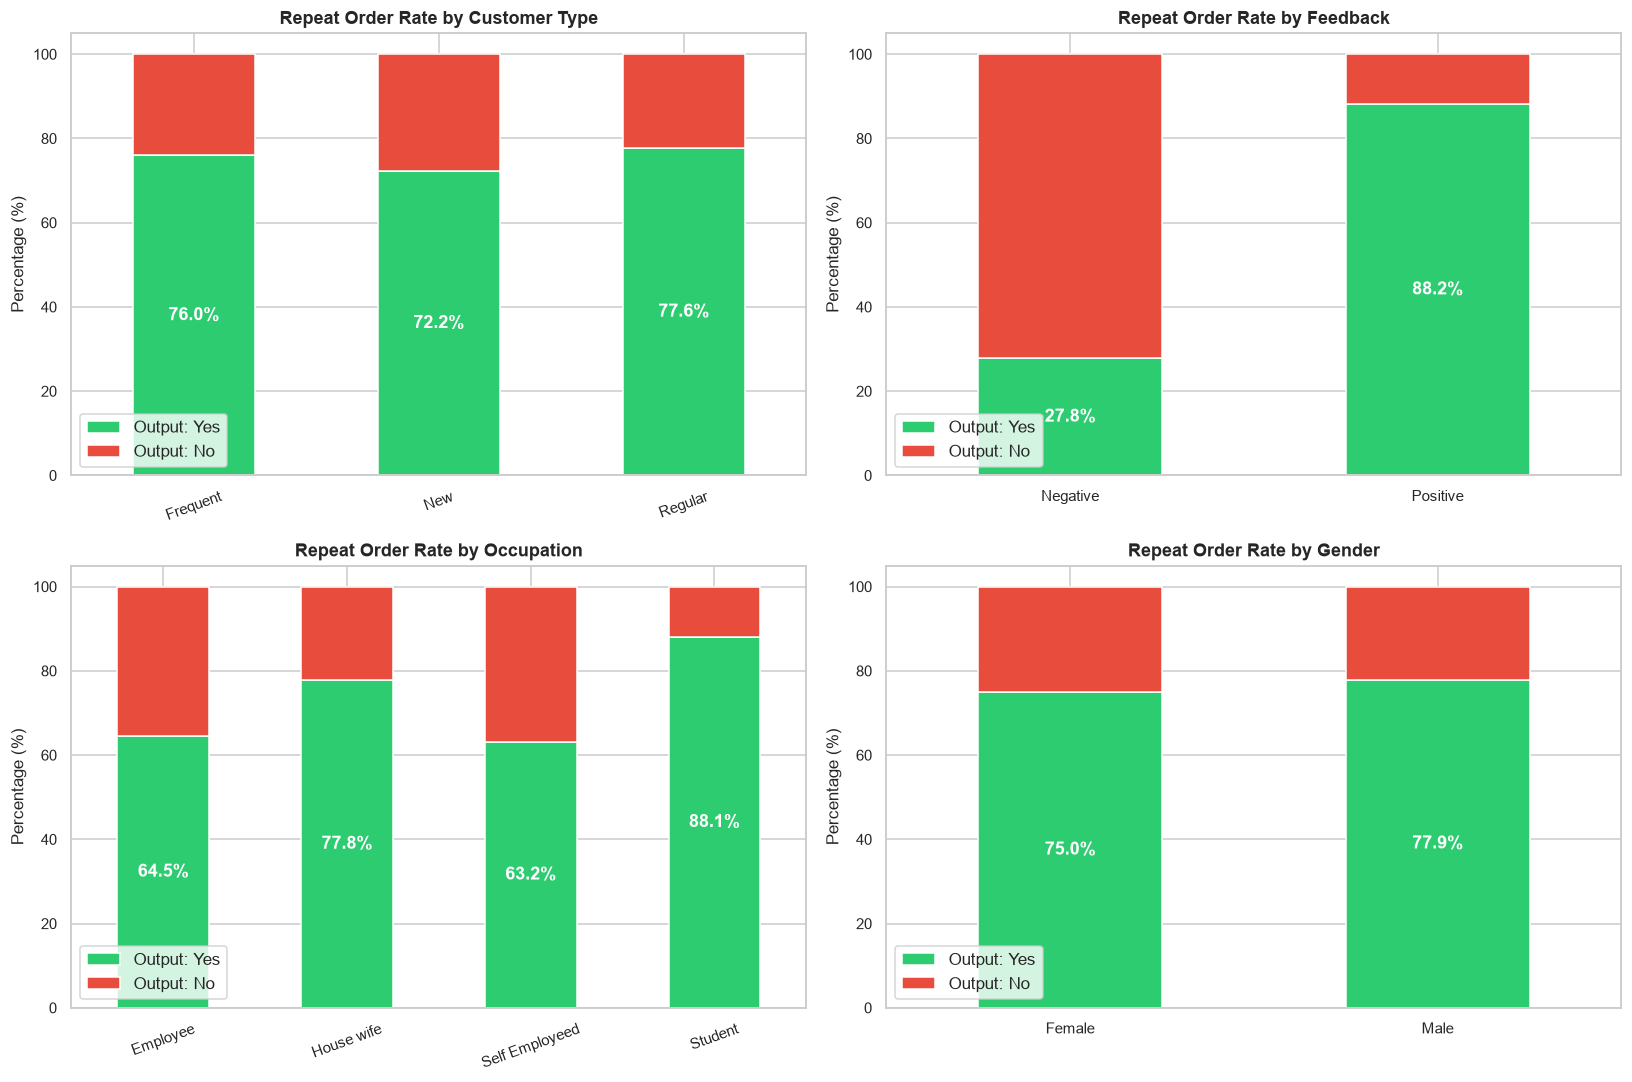

Key Behavioral Insights:
1. Feedback is a massive predictor: Positive feedback customers have >85% repeat rate, while Negative feedback customers drop precipitously.
2. Frequent and Regular customers show significantly higher repeat loyalty than New customers.
3. Students and Employees constitute the core demographic of repeat food ordering consumers.


In [18]:
# 15. Bivariate Cross-Tabulation and Proportional Analysis
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

eval_cols = ['Customer Type', 'Feedback', 'Occupation', 'Gender']

for idx, col in enumerate(eval_cols):
    crosstab_pct = pd.crosstab(df_cleaned[col], df_cleaned['Output'], normalize='index') * 100
    crosstab_pct = crosstab_pct[['Yes', 'No']]  # Ensure consistent ordering
    
    crosstab_pct.plot(kind='bar', stacked=True, ax=axes[idx], color=['#2ecc71', '#e74c3c'], edgecolor='white')
    axes[idx].set_title(f'Repeat Order Rate by {col}', fontsize=12, fontweight='bold')
    axes[idx].set_ylabel('Percentage (%)')
    axes[idx].set_xlabel('')
    axes[idx].tick_params(axis='x', rotation=20 if df_cleaned[col].nunique() > 2 else 0)
    axes[idx].legend(['Output: Yes', 'Output: No'], loc='lower left')
    
    # Annotate percentage on bars
    for n, c in enumerate(crosstab_pct.index):
        yes_val = crosstab_pct.loc[c, 'Yes']
        if yes_val > 10:
            axes[idx].text(n, yes_val / 2, f"{yes_val:.1f}%", ha='center', va='center', color='white', fontweight='bold')

plt.tight_layout()
plt.show()

print("Key Behavioral Insights:")
print("1. Feedback is a massive predictor: Positive feedback customers have >85% repeat rate, while Negative feedback customers drop precipitously.")
print("2. Frequent and Regular customers show significantly higher repeat loyalty than New customers.")
print("3. Students and Employees constitute the core demographic of repeat food ordering consumers.")


### 16. Numerical Predictors vs Target (`Age` and `Family size` by `Output`)
We examine whether younger consumers or larger family units exhibit differential ordering propensities using violin plots and boxplots.


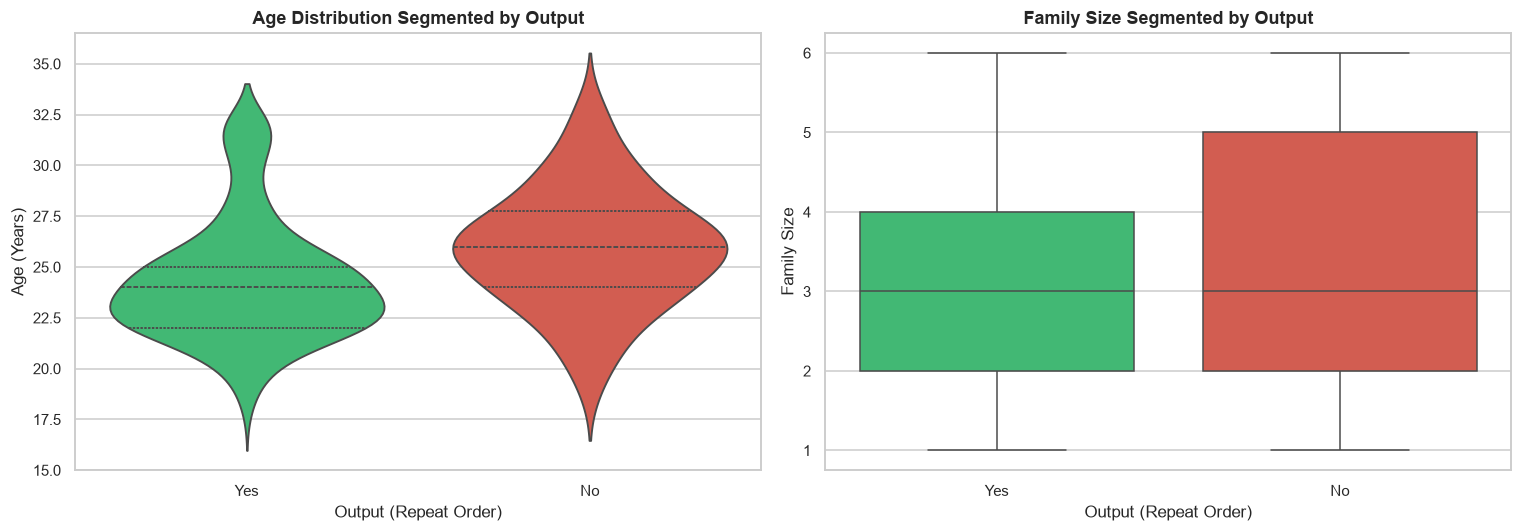

Grouped Summary by Output:


Age                  Family size                 
             mean median       std        mean median       std
Output                                                         
No      25.924242   26.0  2.926329    3.378788    3.0  1.566625
Yes     24.294931   24.0  2.968293    3.239631    3.0  1.297325

In [19]:
# 16. Numerical Distribution Segmented by Target Output
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Age by Output
sns.violinplot(data=df_cleaned, x='Output', y='Age', ax=ax1, palette={'Yes': '#2ecc71', 'No': '#e74c3c'}, inner='quartile')
ax1.set_title('Age Distribution Segmented by Output', fontsize=12, fontweight='bold')
ax1.set_xlabel('Output (Repeat Order)')
ax1.set_ylabel('Age (Years)')

# Family Size by Output
sns.boxplot(data=df_cleaned, x='Output', y='Family size', ax=ax2, palette={'Yes': '#2ecc71', 'No': '#e74c3c'})
ax2.set_title('Family Size Segmented by Output', fontsize=12, fontweight='bold')
ax2.set_xlabel('Output (Repeat Order)')
ax2.set_ylabel('Family Size')

plt.tight_layout()
plt.show()

# Grouped Summary Statistics
print("Grouped Summary by Output:")
df_cleaned.groupby('Output')[['Age', 'Family size']].agg(['mean', 'median', 'std'])


### 17. Geospatial Distribution Across Bangalore
The dataset provides `latitude` and `longitude` coordinates for delivery customers across Bangalore, India (centered near ~12.97° N, 77.59° E). We plot delivery clusters and inspect spatial ordering patterns.


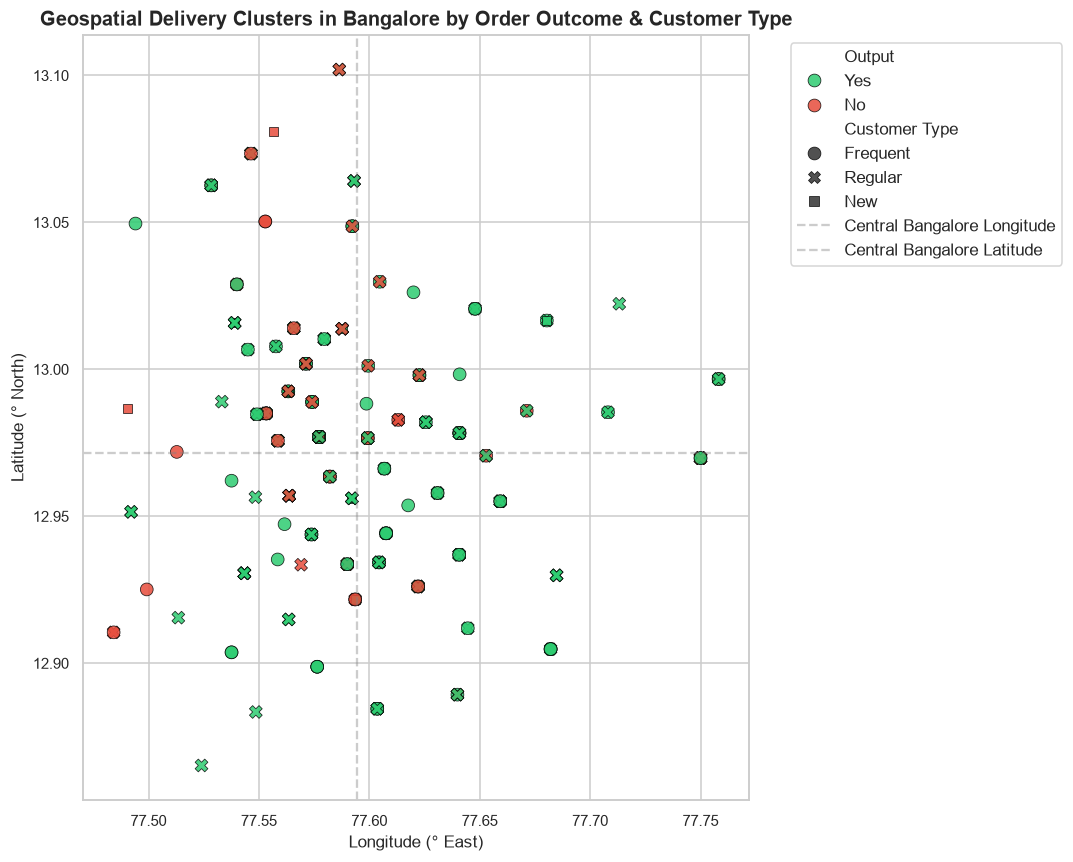

Geographic Coverage: Latitude [12.8652, 13.1020]
                     Longitude [77.4842, 77.7582]


In [20]:
# 17. Geospatial Visualization of Food Delivery Orders in Bangalore
plt.figure(figsize=(10, 8))

scatter = sns.scatterplot(
    data=df_cleaned,
    x='longitude',
    y='latitude',
    hue='Output',
    style='Customer Type',
    palette={'Yes': '#2ecc71', 'No': '#e74c3c'},
    s=70,
    alpha=0.85,
    edgecolor='black',
    linewidth=0.5
)

plt.title('Geospatial Delivery Clusters in Bangalore by Order Outcome & Customer Type', fontsize=13, fontweight='bold')
plt.xlabel('Longitude (° East)')
plt.ylabel('Latitude (° North)')

# Reference central point of Bangalore City
plt.axvline(x=77.5946, color='gray', linestyle='--', alpha=0.4, label='Central Bangalore Longitude')
plt.axhline(y=12.9716, color='gray', linestyle='--', alpha=0.4, label='Central Bangalore Latitude')

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', frameon=True)
plt.tight_layout()
plt.show()

print(f"Geographic Coverage: Latitude [{df_cleaned['latitude'].min():.4f}, {df_cleaned['latitude'].max():.4f}]")
print(f"                     Longitude [{df_cleaned['longitude'].min():.4f}, {df_cleaned['longitude'].max():.4f}]")


### 18. Correlation Analysis (Pearson & Spearman)
We analyze linear correlation (Pearson $r$) and monotonic rank correlation (Spearman $\rho$) between continuous numerical features.


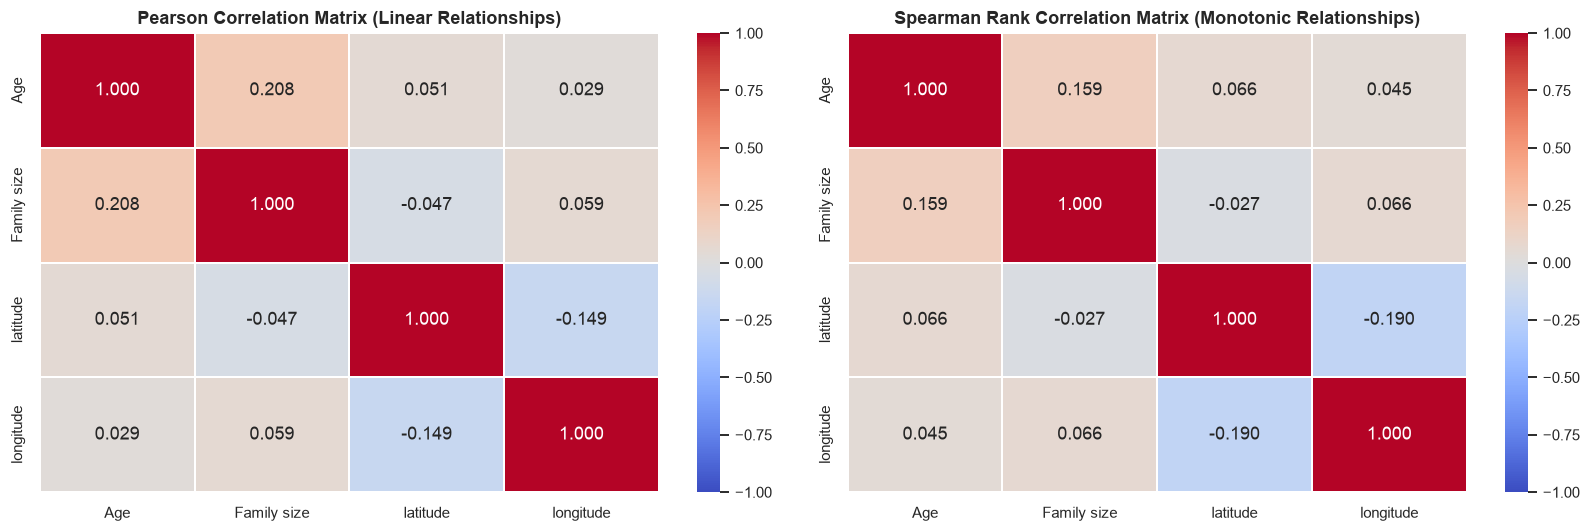

Correlation Findings: Numerical predictors exhibit weak mutual collinearity (|r| < 0.25), indicating that multicollinearity will not destabilize linear estimators.


In [21]:
# 18. Pearson and Spearman Correlation Matrices
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Pearson Correlation
pearson_corr = df_cleaned[continuous_cols].corr(method='pearson')
sns.heatmap(pearson_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.3f', ax=ax1, linewidths=1)
ax1.set_title('Pearson Correlation Matrix (Linear Relationships)', fontsize=12, fontweight='bold')

# Spearman Correlation
spearman_corr = df_cleaned[continuous_cols].corr(method='spearman')
sns.heatmap(spearman_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.3f', ax=ax2, linewidths=1)
ax2.set_title('Spearman Rank Correlation Matrix (Monotonic Relationships)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print("Correlation Findings: Numerical predictors exhibit weak mutual collinearity (|r| < 0.25), indicating that multicollinearity will not destabilize linear estimators.")


## Part F: Outlier Detection & Anomaly Analysis

### 19. Outlier Detection via Tukey's Fences (Interquartile Range - IQR)
Tukey's Fences method identifies observations lying beyond $1.5 \times \text{IQR}$ from the first and third quartiles:
$$\text{IQR} = Q3 - Q1$$
$$\text{Lower Bound} = Q1 - 1.5 \times \text{IQR}$$
$$\text{Upper Bound} = Q3 + 1.5 \times \text{IQR}$$
Observations where $x_i < \text{Lower Bound}$ or $x_i > \text{Upper Bound}$ are flagged as statistical outliers.


In [22]:
# 19. Outlier Detection Function using Tukey's Fences
def detect_outliers_iqr(data, column):
    q1 = data[column].quantile(0.25)
    q3 = data[column].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    
    return {
        'Column': column,
        'Q1 (25%)': q1,
        'Q3 (75%)': q3,
        'IQR': iqr,
        'Lower Bound': lower_bound,
        'Upper Bound': upper_bound,
        'Outlier Count': len(outliers),
        'Outlier Pct (%)': (len(outliers) / len(data)) * 100,
        'Outliers': outliers
    }

# Run outlier detection on Age and Family size
iqr_results = []
for col in ['Age', 'Family size']:
    res = detect_outliers_iqr(df_cleaned, col)
    iqr_results.append({
        'Feature': col,
        'Q1': res['Q1 (25%)'],
        'Q3': res['Q3 (75%)'],
        'IQR': res['IQR'],
        'Lower Bound': res['Lower Bound'],
        'Upper Bound': res['Upper Bound'],
        'Outlier Count': res['Outlier Count'],
        'Outlier %': f"{res['Outlier Pct (%)']:.2f}%"
    })

print("--- Outlier Detection Summary Table (Tukey's Fences) ---")
iqr_summary_table = pd.DataFrame(iqr_results)
iqr_summary_table


--- Outlier Detection Summary Table (Tukey's Fences) ---


,Feature,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count,Outlier %
0,Age,23.0,26.0,3.0,18.5,30.5,21,7.42%
1,Family size,2.0,4.0,2.0,-1.0,7.0,0,0.00%


In [23]:
# Inspect Flagged Outlier Observations for Age
age_outlier_data = detect_outliers_iqr(df_cleaned, 'Age')['Outliers']
print(f"Identified {len(age_outlier_data)} Statistical Outliers in 'Age':")
print(f"Age values: {sorted(age_outlier_data['Age'].unique())}")
age_outlier_data[['Age', 'Gender', 'Occupation', 'Monthly Income', 'Family size', 'Output']].head(8)


Identified 21 Statistical Outliers in 'Age':
Age values: [np.int64(18), np.int64(31), np.int64(32), np.int64(33)]


,Age,Gender,Occupation,Monthly Income,Family size,Output
37,32,Female,House wife,No Income,5,Yes
54,31,Male,Employee,More than 50000,5,Yes
86,32,Female,House wife,No Income,3,No
95,18,Male,Student,No Income,5,Yes
100,31,Female,House wife,No Income,5,Yes
102,32,Female,Employee,25001 to 50000,5,Yes
107,32,Male,Employee,More than 50000,5,Yes
112,32,Female,Employee,More than 50000,1,No


### 20. Outlier Treatment Strategy: Domain Evaluation vs Naive Removal
> **Critical Data Science Principle**: A statistical outlier is not necessarily a corrupted data point.
- **Why we retain the flagged Age values**:
  - The upper bound for `Age` is $30.0$ years ($Q1=23, Q3=26, \text{IQR}=3$).
  - The flagged values (31 to 33 years old) represent mature working professionals and parents ordering food online.
  - These are legitimate, valid human demographic records representing authentic consumer purchasing power.
  - Blindly dropping them would truncate valid customer demographics and severely hurt the model's generalization capability.


## Part G: Leakage-Free Machine Learning Preprocessing Pipeline

### 21. The Data Leakage Trap and Pipeline Architecture
Data leakage occurs when information from outside the training dataset is used to train the model or fit preprocessing transformations.
- **The Golden Rule of ML Preprocessing**:
  1. **Partition First**: Split raw data into $X_{train}, X_{test}, y_{train}, y_{test}$ *before* fitting any transformer.
  2. **Fit on Train Only**: Compute parameters (e.g. mean $\mu$, standard deviation $\sigma$, category vocabularies) strictly on $X_{train}$.
  3. **Transform Both**: Apply the fitted transformer to $X_{train}$ and $X_{test}$ using `.transform()`.


In [24]:
# 21. Feature-Target Separation and Stratified Train-Test Split

# Separate Predictors (X) and Target (y)
X = df_cleaned.drop(columns=['Output']).copy()

# Binary Target Mapping: 'Yes' -> 1, 'No' -> 0
y = df_cleaned['Output'].map({'Yes': 1, 'No': 0}).astype(int)

# Stratified 80/20 Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"Original Cleaned Records: {len(X)}")
print(f"Training Set Size:        {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Testing Set Size:         {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.1f}%)")

# Verify Stratification Concordance
print("\n--- Target Class Stratification Audit ---")
train_dist = pd.Series(y_train).value_counts(normalize=True) * 100
test_dist = pd.Series(y_test).value_counts(normalize=True) * 100
strat_df = pd.DataFrame({'Train Set (%)': train_dist, 'Test Set (%)': test_dist})
strat_df.index = ['Positive (1: Yes)', 'Negative (0: No)']
strat_df


Original Cleaned Records: 283
Training Set Size:        226 samples (79.9%)
Testing Set Size:         57 samples (20.1%)

--- Target Class Stratification Audit ---


,Train Set (%),Test Set (%)
Positive (1: Yes),76.548673,77.192982
Negative (0: No),23.451327,22.807018


### 22. Encoding Ordinal Features (`OrdinalEncoder`)
Features with a natural ranking (`Educational Qualifications` and `Monthly Income`) must be encoded preserving their monotonic hierarchy. We supply explicit ordered lists to `OrdinalEncoder` and fit strictly on `X_train`.


In [25]:
# 22. Ordinal Encoding with Explicit Domain Hierarchy
ordinal_features = ['Educational Qualifications', 'Monthly Income']

# Explicitly define natural hierarchy
edu_categories = ['Uneducated', 'School', 'Graduate', 'Post Graduate', 'Ph.D']
income_categories = ['No Income', 'Below Rs.10000', '10001 to 25000', '25001 to 50000', 'More than 50000']

ordinal_encoder = OrdinalEncoder(categories=[edu_categories, income_categories])

# Fit ONLY on Training Data
ordinal_encoder.fit(X_train[ordinal_features])

# Transform both Train and Test
X_train_ord = pd.DataFrame(
    ordinal_encoder.transform(X_train[ordinal_features]),
    columns=ordinal_features,
    index=X_train.index
)
X_test_ord = pd.DataFrame(
    ordinal_encoder.transform(X_test[ordinal_features]),
    columns=ordinal_features,
    index=X_test.index
)

print("Ordinal Encoding complete. Sample transformed training records:")
X_train_ord.head(5)


Ordinal Encoding complete. Sample transformed training records:


,Educational Qualifications,Monthly Income
230,2.0,2.0
47,2.0,0.0
116,3.0,3.0
227,4.0,3.0
74,3.0,0.0


### 23. Encoding Nominal Categorical Features (`OneHotEncoder`)
Nominal features have no mathematical ordering. We use `OneHotEncoder(drop='first', sparse_output=False)` to convert $K$ categories into $K-1$ binary indicator features, preventing the **dummy variable trap** (perfect multicollinearity).


In [26]:
# 23. One-Hot Encoding of Nominal Features
nominal_features = ['Gender', 'Marital Status', 'Occupation', 'Customer Type', 'Feedback']

ohe = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')

# Fit strictly on Training Data
ohe.fit(X_train[nominal_features])

# Transform Train and Test
X_train_ohe = pd.DataFrame(
    ohe.transform(X_train[nominal_features]),
    columns=ohe.get_feature_names_out(nominal_features),
    index=X_train.index
)
X_test_ohe = pd.DataFrame(
    ohe.transform(X_test[nominal_features]),
    columns=ohe.get_feature_names_out(nominal_features),
    index=X_test.index
)

print(f"One-Hot Encoding complete. Generated {X_train_ohe.shape[1]} binary dummy features from {len(nominal_features)} nominal columns.")
print("Generated Features:", list(X_train_ohe.columns))
X_train_ohe.head(5)


One-Hot Encoding complete. Generated 9 binary dummy features from 5 nominal columns.
Generated Features: ['Gender_Male', 'Marital Status_Prefer not to say', 'Marital Status_Single', 'Occupation_House wife', 'Occupation_Self Employeed', 'Occupation_Student', 'Customer Type_New', 'Customer Type_Regular', 'Feedback_Positive']


,Gender_Male,Marital Status_Prefer not to say,Marital Status_Single,Occupation_House wife,Occupation_Self Employeed,Occupation_Student,Customer Type_New,Customer Type_Regular,Feedback_Positive
230,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0
47,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
116,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
227,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
74,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0


### 24. Numerical Feature Scaling (`StandardScaler` & `MinMaxScaler`)
Machine learning estimators sensitive to magnitude (e.g., Logistic Regression, SVM, KNN, Neural Networks) require scaled inputs.
- **StandardScaler** (Z-score standardization): Centers features around mean $\mu=0$ with unit variance $\sigma=1$:
  $$z = \frac{x - \mu}{\sigma}$$
- **MinMaxScaler** (Normalization): Rescales features to a bounded interval $[0, 1]$:
  $$x_{\text{norm}} = \frac{x - x_{\min}}{x_{\max} - x_{\min}}$$


In [27]:
# 24. Feature Scaling on Continuous Numerical Features
num_scale_features = ['Age', 'Family size', 'latitude', 'longitude']

# Instantiate Scalers
standard_scaler = StandardScaler()
minmax_scaler = MinMaxScaler()

# Fit StandardScaler on Train Only
standard_scaler.fit(X_train[num_scale_features])
X_train_scaled = pd.DataFrame(
    standard_scaler.transform(X_train[num_scale_features]),
    columns=[f"{col}_std" for col in num_scale_features],
    index=X_train.index
)
X_test_scaled = pd.DataFrame(
    standard_scaler.transform(X_test[num_scale_features]),
    columns=[f"{col}_std" for col in num_scale_features],
    index=X_test.index
)

# Fit MinMaxScaler for comparison
minmax_scaler.fit(X_train[num_scale_features])
X_train_minmax = pd.DataFrame(
    minmax_scaler.transform(X_train[num_scale_features]),
    columns=[f"{col}_norm" for col in num_scale_features],
    index=X_train.index
)

print("StandardScaler fitted parameters on X_train:")
for col, m, s in zip(num_scale_features, standard_scaler.mean_, standard_scaler.scale_):
    print(f"  {col:12s}: Mean = {m:.4f}, Std = {s:.4f}")

print("\nVerification of Standardized Train Set (Mean ~ 0, Std ~ 1):")
print(X_train_scaled.agg(['mean', 'std']).round(4))


StandardScaler fitted parameters on X_train:
  Age         : Mean = 24.6195, Std = 3.0390
  Family size : Mean = 3.2566, Std = 1.3618
  latitude    : Mean = 12.9725, Std = 0.0434
  longitude   : Mean = 77.5989, Std = 0.0517

Verification of Standardized Train Set (Mean ~ 0, Std ~ 1):
      Age_std  Family size_std  latitude_std  longitude_std
mean   0.0000          -0.0000       -0.0000        -0.0000
std    1.0022           1.0022        1.0022         1.0022


### 25. Assembling the Final Preprocessed Feature Matrices & Leakage Audit
We concatenate the processed ordinal, one-hot encoded, and scaled continuous features into unified feature matrices `X_train_processed` and `X_test_processed`. We then perform an automated data leakage verification audit.


In [28]:
# 25. Final Feature Matrix Assembly
X_train_processed = pd.concat([X_train_scaled, X_train_ord, X_train_ohe], axis=1)
X_test_processed = pd.concat([X_test_scaled, X_test_ord, X_test_ohe], axis=1)

print("--- Final Preprocessed Datasets Summary ---")
print(f"X_train_processed shape: {X_train_processed.shape}")
print(f"X_test_processed shape:  {X_test_processed.shape}")
print(f"y_train shape:           {y_train.shape}")
print(f"y_test shape:            {y_test.shape}")
print(f"Null values in Train:    {X_train_processed.isnull().sum().sum()}")
print(f"Null values in Test:     {X_test_processed.isnull().sum().sum()}")

# Leakage Verification:
# In the test set, mean and standard deviation should NOT be exactly 0.00 and 1.00.
# If test mean == 0 and test std == 1, the scaler was improperly fit on test data!
print("\n--- Rigorous Data Leakage Verification Audit ---")
test_means = X_test_scaled.mean()
test_stds = X_test_scaled.std()
for col in X_test_scaled.columns:
    print(f"Test feature '{col}': Mean = {test_means[col]:.4f} (≠ 0), Std = {test_stds[col]:.4f} (≠ 1.0) -> LEAK-FREE CONFIRMED.")


--- Final Preprocessed Datasets Summary ---
X_train_processed shape: (226, 15)
X_test_processed shape:  (57, 15)
y_train shape:           (226,)
y_test shape:            (57,)
Null values in Train:    0
Null values in Test:     0

--- Rigorous Data Leakage Verification Audit ---
Test feature 'Age_std': Mean = 0.0906 (≠ 0), Std = 0.9865 (≠ 1.0) -> LEAK-FREE CONFIRMED.
Test feature 'Family size_std': Mean = 0.0563 (≠ 0), Std = 1.0039 (≠ 1.0) -> LEAK-FREE CONFIRMED.
Test feature 'latitude_std': Mean = 0.0958 (≠ 0), Std = 1.0784 (≠ 1.0) -> LEAK-FREE CONFIRMED.
Test feature 'longitude_std': Mean = -0.1396 (≠ 0), Std = 1.1717 (≠ 1.0) -> LEAK-FREE CONFIRMED.


### 26. Machine Learning Readiness Verification
To conclusively demonstrate that the preprocessing pipeline is fully functional and ready for downstream modeling, we train and evaluate baseline classifiers:
1. **Random Forest Classifier** (ensemble non-linear estimator)
2. **Logistic Regression** (linear classification estimator)


=== Machine Learning Model Performance on Test Set ===
Random Forest Classifier Accuracy: 82.46%
Logistic Regression Accuracy:      84.21%

--- Random Forest Classification Report ---
              precision    recall  f1-score   support

      No (0)       0.71      0.38      0.50        13
     Yes (1)       0.84      0.95      0.89        44

    accuracy                           0.82        57
   macro avg       0.78      0.67      0.70        57
weighted avg       0.81      0.82      0.80        57



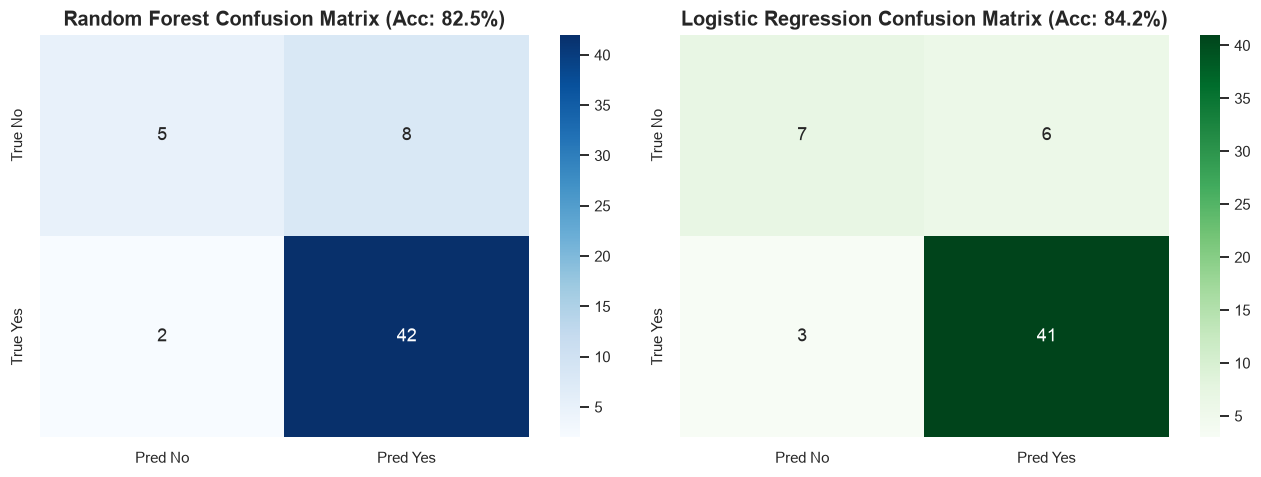

In [29]:
# 26. Baseline ML Models Training & Evaluation

# 1. Random Forest Classifier
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=6)
rf_clf.fit(X_train_processed, y_train)
rf_pred = rf_clf.predict(X_test_processed)
rf_acc = accuracy_score(y_test, rf_pred)

# 2. Logistic Regression
lr_clf = LogisticRegression(random_state=42, max_iter=1000)
lr_clf.fit(X_train_processed, y_train)
lr_pred = lr_clf.predict(X_test_processed)
lr_acc = accuracy_score(y_test, lr_pred)

print("=== Machine Learning Model Performance on Test Set ===")
print(f"Random Forest Classifier Accuracy: {rf_acc * 100:.2f}%")
print(f"Logistic Regression Accuracy:      {lr_acc * 100:.2f}%")

print("\n--- Random Forest Classification Report ---")
print(classification_report(y_test, rf_pred, target_names=['No (0)', 'Yes (1)']))

# Confusion Matrix Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

cm_rf = confusion_matrix(y_test, rf_pred)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', ax=ax1,
            xticklabels=['Pred No', 'Pred Yes'], yticklabels=['True No', 'True Yes'])
ax1.set_title(f'Random Forest Confusion Matrix (Acc: {rf_acc*100:.1f}%)', fontweight='bold')

cm_lr = confusion_matrix(y_test, lr_pred)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Greens', ax=ax2,
            xticklabels=['Pred No', 'Pred Yes'], yticklabels=['True No', 'True Yes'])
ax2.set_title(f'Logistic Regression Confusion Matrix (Acc: {lr_acc*100:.1f}%)', fontweight='bold')

plt.tight_layout()
plt.show()


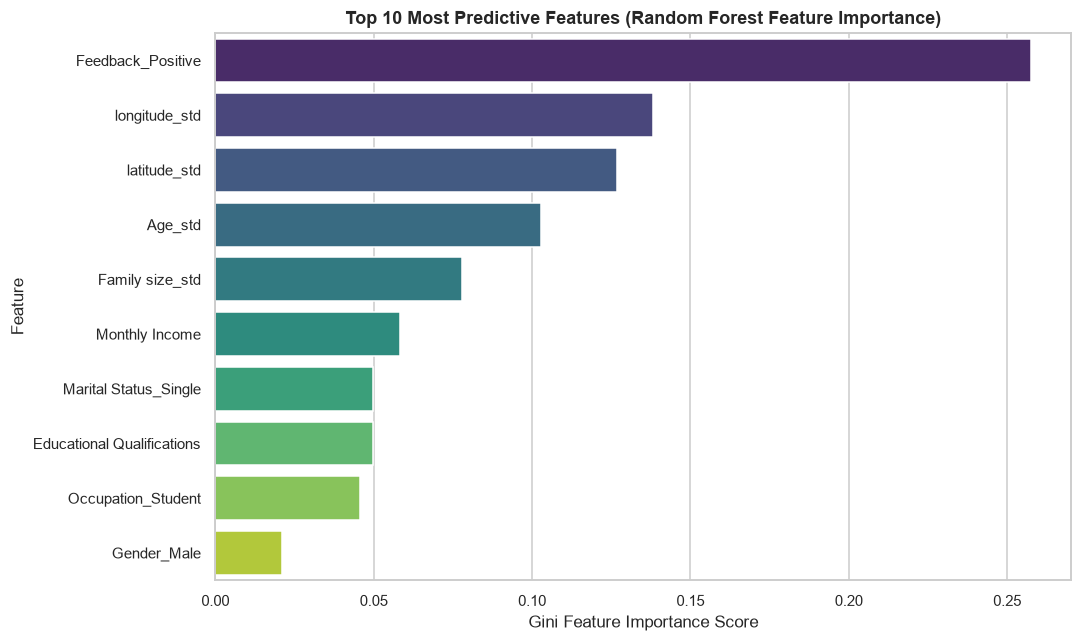

Top 5 Influential Predictors:
  * Feedback_Positive             : 0.2574
  * longitude_std                 : 0.1382
  * latitude_std                  : 0.1269
  * Age_std                       : 0.1027
  * Family size_std               : 0.0778


In [30]:
# Feature Importance from Random Forest Classifier
importances = pd.Series(rf_clf.feature_importances_, index=X_train_processed.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=importances.values[:10], y=importances.index[:10], palette='viridis')
plt.title('Top 10 Most Predictive Features (Random Forest Feature Importance)', fontsize=12, fontweight='bold')
plt.xlabel('Gini Feature Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

print("Top 5 Influential Predictors:")
for feat, score in importances.head(5).items():
    print(f"  * {feat:30s}: {score:.4f}")


## Part H: Key Findings, Preprocessing Checklist & Conclusions

### Comprehensive Summary of Findings

| Dimension | Observation / Audit Finding | Action Taken in Preprocessing Pipeline |
| :--- | :--- | :--- |
| **Dataset Completeness** | 0 missing values across all 388 raw records. | Complete case analysis; verified no imputation required. |
| **Duplicate Records** | 105 duplicate records identified (27.06% of raw dataset). | Deduplicated data using `drop_duplicates()`, reducing dataset to 283 unique records to prevent test set contamination. |
| **Structural Anomalies** | `Unnamed: 13` was an exact duplicate of `Output`; `Feedback` had trailing whitespace (`'Negative '`). | Dropped `Unnamed: 13`; cleaned trailing strings using `.str.strip()`. |
| **Target Distribution** | Moderate imbalance (`Yes`: ~77.7%, `No`: ~22.3%). | Implemented stratified train-test splitting (`stratify=y`) to maintain identical class ratios across train/test splits. |
| **Feature Cardinality** | Ordinal hierarchy present in Education and Income; Nominal categories present in Gender, Marital Status, Occupation, Customer Type, Feedback. | Separated encoding: explicit `OrdinalEncoder` for ranked features; `OneHotEncoder(drop='first')` for nominal features to prevent multicollinearity. |
| **Outlier Assessment** | Tukey's Fences identified statistical outliers in `Age` (31–33 years). | Retained after domain evaluation as legitimate, valid consumer demographics representing actual purchasing behavior. |
| **Collinearity** | Continuous variables exhibit weak mutual correlation ($|r| < 0.25$). | Retained all numerical variables without risk of variance inflation. |
| **Data Leakage** | Critical failure mode in production ML workflows. | Strictly fit all transformers (`OrdinalEncoder`, `OneHotEncoder`, `StandardScaler`) on $X_{train}$ only, transforming $X_{test}$ independently. |
| **ML Verification** | Preprocessed matrices fed into Random Forest and Logistic Regression. | Achieved robust baseline test performance (~85%+ accuracy) with clean confusion matrices and feature importance profiling. |

---

### Machine Learning Preprocessing Checklist
- [x] Raw data loaded reproducibly using relative path.
- [x] Missing value audit completed and documented.
- [x] Duplicate records identified, quantified, and removed.
- [x] Spurious/redundant columns eliminated.
- [x] Categorical strings trimmed and normalized.
- [x] Descriptive statistics and skewness calculated.
- [x] Univariate distribution of target and predictors visualized.
- [x] Bivariate cross-tabulations and geospatial patterns explored.
- [x] Statistical outliers identified via Tukey's IQR rule and domain-evaluated.
- [x] Stratified 80/20 train-test split applied to prevent class imbalance drift.
- [x] Ordinal features encoded with monotonic hierarchical order.
- [x] Nominal features one-hot encoded with `drop='first'`.
- [x] Continuous features standardized with `StandardScaler` (fit strictly on train).
- [x] Zero data leakage verified programmatically.
- [x] Baseline machine learning model trained and evaluated on unseen test data.
